# 02 - Preprocessing Demo

Runs the AeroMind preprocessing pipeline (`src/preprocessing`) on one synthetic subject and visualizes each stage: raw, filtered, bad-channel handling, ICA-cleaned, and final epoched/z-scored data. No external dataset needed.

In [1]:
import matplotlib.pyplot as plt
import mne
import numpy as np

from src.preprocessing.run import synthetic_raw, preprocess_raw
from src.preprocessing.filters import apply_standard_filters
from src.preprocessing.prep_pipeline import detect_bad_channels, interpolate_bad_channels, robust_average_reference
from src.preprocessing.ica_artefact import remove_artefacts
from src.preprocessing.epoching import epoch_continuous

mne.set_log_level('ERROR')

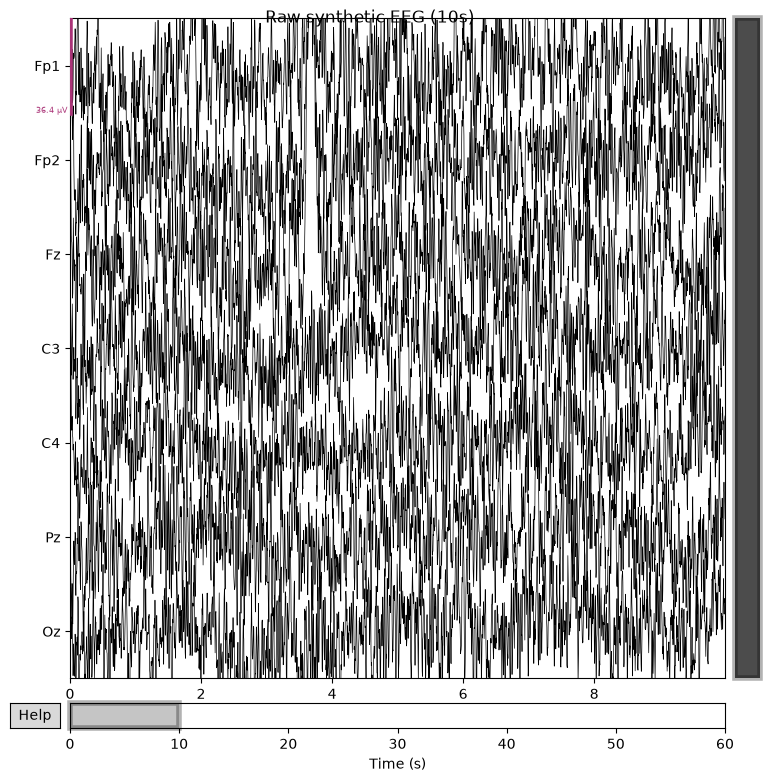

In [2]:
raw = synthetic_raw(subject_id=0, duration_s=60.0, sfreq=256.0, seed=1)
raw.plot(duration=10, n_channels=7, scalings='auto', show=False)
plt.gcf().suptitle('Raw synthetic EEG (10s)')
plt.show()

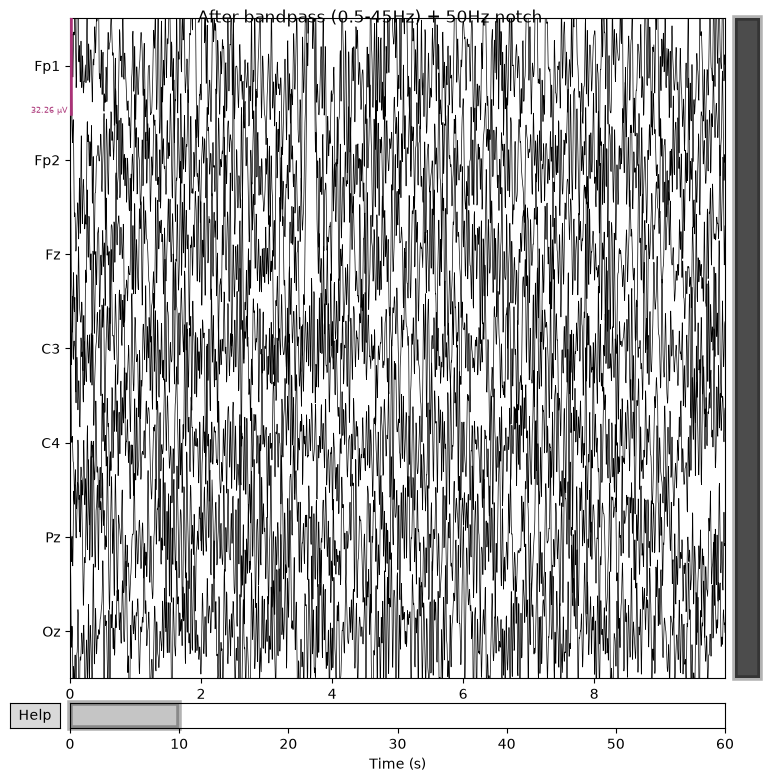

In [3]:
filtered = apply_standard_filters(raw.get_data(), raw.info['sfreq'])
raw_filt = mne.io.RawArray(filtered, raw.info, verbose=False)
raw_filt.plot(duration=10, n_channels=7, scalings='auto', show=False)
plt.gcf().suptitle('After bandpass (0.5-45Hz) + 50Hz notch')
plt.show()

In [4]:
bad_report = detect_bad_channels(raw_filt)
print('Flagged bad channels:', bad_report.all_bad)
raw_interp = interpolate_bad_channels(raw_filt, bad_report)
raw_ref = robust_average_reference(raw_interp)

Flagged bad channels: ['Fp1', 'Fz']


Z:\aeromind\src\preprocessing\prep_pipeline.py:92: RuntimeWarning: Only 7 head digitization points of the specified kinds ("eeg", "extra",), fitting may be inaccurate
  raw.interpolate_bads(reset_bads=True, verbose=False)


Z:\aeromind\src\preprocessing\ica_artefact.py:49: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, verbose=False)


Z:\aeromind\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ICA method: iclabel
Components excluded: [] / 4


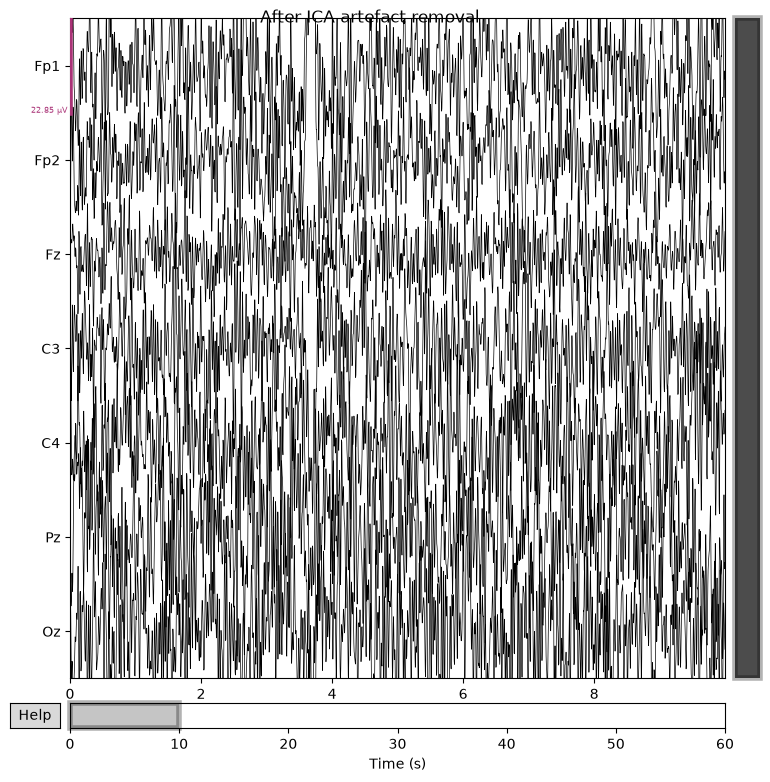

In [5]:
cleaned, ica_report = remove_artefacts(raw_ref)
print('ICA method:', ica_report.method)
print('Components excluded:', ica_report.excluded, '/', ica_report.n_components)
cleaned.plot(duration=10, n_channels=7, scalings='auto', show=False)
plt.gcf().suptitle('After ICA artefact removal')
plt.show()

Kept 59/59 epochs
Epoch tensor shape (n_epochs, n_channels, n_samples): (59, 7, 512)


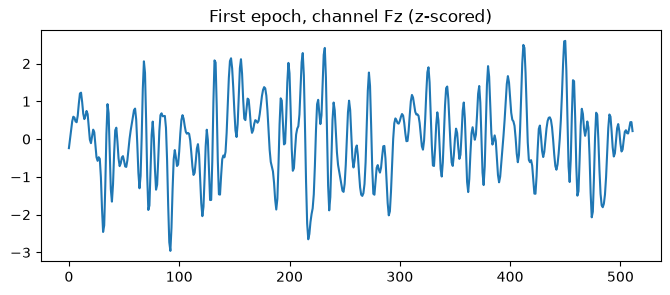

In [6]:
result = epoch_continuous(cleaned, epoch_seconds=2.0, overlap=0.5)
print(f'Kept {result.n_total - result.n_rejected}/{result.n_total} epochs')
print('Epoch tensor shape (n_epochs, n_channels, n_samples):', result.data.shape)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(result.data[0, 2, :])  # channel 2 = Fz, first epoch
ax.set_title('First epoch, channel Fz (z-scored)')
plt.show()

In [7]:
# End-to-end via the CLI's preprocess_raw() in one call
data = preprocess_raw(raw, sfreq_target=256.0, window=2.0, overlap=0.5)
print('Final preprocessed tensor:', data.shape)

00:34:02 | INFO    | src.preprocessing.run | Interpolating bad channels: ['Fp1', 'Fz']


Z:\aeromind\src\preprocessing\prep_pipeline.py:92: RuntimeWarning: Only 7 head digitization points of the specified kinds ("eeg", "extra",), fitting may be inaccurate
  raw.interpolate_bads(reset_bads=True, verbose=False)
Z:\aeromind\src\preprocessing\ica_artefact.py:49: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw, verbose=False)


00:34:03 | INFO    | src.preprocessing.run | ICA (iclabel) excluded 0/4 components


00:34:03 | INFO    | src.preprocessing.run | Kept 59/59 epochs (0 rejected)


Final preprocessed tensor: (59, 7, 512)
